<a href="https://colab.research.google.com/github/MLfinal/Walmart-Recruiting---Store-Sales-Forecasting/blob/dev/models/deep_learning/tft/model_experiment_TFT_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TFT experiment v2 — log target + external covariates

v1 result on top 500 active Store-Dept series:
- seasonal naive WMAE: `4969.77`
- TFT v1 WMAE: `6200.95`
- v1 improved over fast baseline but still underperformed seasonal naive.

v2 keeps the same external covariates and controlled top-500 sample, but changes the target strategy:
- train TFT on `SalesLog = log1p(clipped Weekly_Sales)`;
- inverse-transform predictions with `expm1` before computing Kaggle WMAE;
- keep WMAE on original sales scale as the model-selection metric.

Why: v1 trained directly on large raw sales values. TFT had difficulty with scale across Store-Dept series. A log target can make the optimization problem smoother and reduce domination by the largest departments.

This is still a controlled experiment, not full-data final TFT.

In [37]:
%pip install -q "torch>=2.3,<3" "pytorch-forecasting>=1.2,<2" "lightning>=2.2,<3" "wandb>=0.19,<1" "pandas>=2.2,<3" "numpy>=1.26,<3" "matplotlib>=3.8,<4" "scikit-learn>=1.4,<2"

In [38]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import wandb

try:
    from lightning.pytorch import Trainer, seed_everything
    from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint
    from lightning.pytorch.loggers import WandbLogger
except Exception:
    from pytorch_lightning import Trainer, seed_everything
    from pytorch_lightning.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint
    from pytorch_lightning.loggers import WandbLogger

from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import MAE

pd.set_option('display.max_columns', 120)
print('torch', torch.__version__)
print('cuda available:', torch.cuda.is_available())

torch 2.11.0+cu128
cuda available: True


In [41]:
SEED = 42
seed_everything(SEED, workers=True)

CONFIG = {
    "seed": SEED,
    "validation_weeks": 39,
    "encoder_weeks": 39,
    "top_n_series": 500,
    "holiday_weight": 5.0,
    "batch_size": 512,
    "max_epochs": 10,
    "max_time_minutes": 25,
    "patience": 3,
    "learning_rate": 1e-4,
    "hidden_size": 16,
    "attention_head_size": 2,
    "dropout": 0.10,
    "hidden_continuous_size": 8,
    "gradient_clip_val": 0.1,
    "num_workers": 0,
    "limit_train_batches": 50,
    "limit_val_batches": 8,
    "baseline_top300_wmae": 7801.898566783023,
    "v1_top500_wmae": 6200.954359119016,
    "v1_top500_seasonal_naive_wmae": 4969.768735310006,
    "wandb_project": "Walmart-Recruiting---Store-Sales-Forecasting",
    "wandb_entity": "kende23-n-a",
    "wandb_group": "tft-experiments",
    "run_name": "tft_v2_log_target_external_covariates",
    "artifact_name": "tft-v2-log-target-external-covariates",
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}

DATA_DIR = Path('/content/drive/MyDrive/walmart_competition_data')
OUTPUT_DIR = Path('/content/artifacts/tft_v2_log_target')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


{'seed': 42,
 'validation_weeks': 39,
 'encoder_weeks': 39,
 'top_n_series': 500,
 'holiday_weight': 5.0,
 'batch_size': 512,
 'max_epochs': 10,
 'max_time_minutes': 25,
 'patience': 3,
 'learning_rate': 0.0001,
 'hidden_size': 16,
 'attention_head_size': 2,
 'dropout': 0.1,
 'hidden_continuous_size': 8,
 'gradient_clip_val': 0.1,
 'num_workers': 0,
 'limit_train_batches': 50,
 'limit_val_batches': 8,
 'baseline_top300_wmae': 7801.898566783023,
 'v1_top500_wmae': 6200.954359119016,
 'v1_top500_seasonal_naive_wmae': 4969.768735310006,
 'wandb_project': 'Walmart-Recruiting---Store-Sales-Forecasting',
 'wandb_entity': 'kende23-n-a',
 'wandb_group': 'tft-experiments',
 'run_name': 'tft_v2_log_target_external_covariates',
 'artifact_name': 'tft-v2-log-target-external-covariates',
 'device': 'cuda'}

## Load data and keep top active series

We keep top 500 series to compare v2 with v1 on the same scale. If v2 cannot beat seasonal naive here, full-data training is not justified yet.

In [42]:
train_raw = pd.read_csv(DATA_DIR / 'train.csv', parse_dates=['Date'])
test_raw = pd.read_csv(DATA_DIR / 'test.csv', parse_dates=['Date'])
features_raw = pd.read_csv(DATA_DIR / 'features.csv', parse_dates=['Date'])
stores_raw = pd.read_csv(DATA_DIR / 'stores.csv')

required_train = {'Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday'}
required_features = {'Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment'}
required_stores = {'Store', 'Type', 'Size'}
missing = {
    'train': sorted(required_train.difference(train_raw.columns)),
    'features': sorted(required_features.difference(features_raw.columns)),
    'stores': sorted(required_stores.difference(stores_raw.columns)),
}
if any(missing.values()):
    raise ValueError(missing)

train_raw = train_raw.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)
test_raw = test_raw.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)
features_raw = features_raw.sort_values(['Store', 'Date']).reset_index(drop=True)
stores_raw = stores_raw.sort_values('Store').reset_index(drop=True)

if CONFIG['top_n_series'] is not None:
    top_series = (
        train_raw.groupby(['Store', 'Dept'], as_index=False)['Weekly_Sales']
        .sum()
        .sort_values('Weekly_Sales', ascending=False)
        .head(CONFIG['top_n_series'])[['Store', 'Dept']]
    )
    before_rows = len(train_raw)
    train_raw = train_raw.merge(top_series.assign(_keep=1), on=['Store', 'Dept'], how='inner').drop(columns='_keep')
    print({'top_n_series': CONFIG['top_n_series'], 'train_rows_before': before_rows, 'train_rows_after': len(train_raw)})

print('train', train_raw.shape, train_raw['Date'].min(), train_raw['Date'].max())
print('features', features_raw.shape, features_raw['Date'].min(), features_raw['Date'].max())
print('stores', stores_raw.shape)
display(train_raw.head())

{'top_n_series': 500, 'train_rows_before': 421570, 'train_rows_after': 71500}
train (71500, 5) 2010-02-05 00:00:00 2012-10-26 00:00:00
features (8190, 12) 2010-02-05 00:00:00 2013-07-26 00:00:00
stores (45, 3)


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,2,2010-02-05,50605.27,False
1,1,2,2010-02-12,44682.74,True
2,1,2,2010-02-19,47928.89,False
3,1,2,2010-02-26,44292.87,False
4,1,2,2010-03-05,48397.98,False


## Merge covariates and create log target

In [43]:
all_train_dates = pd.Index(sorted(train_raw['Date'].unique()), name='Date')
test_dates = pd.Index(sorted(test_raw['Date'].unique()), name='Date')
val_dates = all_train_dates[-CONFIG['validation_weeks']:]
fit_dates = all_train_dates[:-CONFIG['validation_weeks']]
split_pos = len(fit_dates)

if len(test_dates) != CONFIG['validation_weeks']:
    raise ValueError(f"Expected test horizon {CONFIG['validation_weeks']}, got {len(test_dates)}")
if len(fit_dates) < CONFIG['encoder_weeks'] + CONFIG['validation_weeks']:
    raise ValueError('Not enough fit history for encoder + decoder windows.')

date_to_idx = {date: idx for idx, date in enumerate(all_train_dates)}

COVARIATE_REALS = [
    'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5',
    'CPI', 'Unemployment', 'Size'
]
CALENDAR_REALS = ['time_idx', 'week_sin', 'week_cos', 'month_sin', 'month_cos']
KNOWN_REALS = CALENDAR_REALS + COVARIATE_REALS
TARGET_COL = 'SalesLog'

def make_model_frame(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    feat = features_raw.drop(columns=[c for c in ['IsHoliday'] if c in features_raw.columns])
    out = out.merge(feat, on=['Store', 'Date'], how='left')
    out = out.merge(stores_raw, on='Store', how='left')

    markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
    out[markdown_cols] = out[markdown_cols].fillna(0.0)
    for col in ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']:
        out[col] = out.groupby('Store')[col].transform(lambda s: s.ffill().bfill())
        out[col] = out[col].fillna(out[col].median())
    out['Size'] = out['Size'].fillna(out['Size'].median())
    out['Type'] = out['Type'].fillna('Unknown')

    out['Weekly_Sales_Original'] = out['Weekly_Sales'].astype(float)
    out['Weekly_Sales_Clipped'] = out['Weekly_Sales_Original'].clip(lower=0.0)
    out[TARGET_COL] = np.log1p(out['Weekly_Sales_Clipped']).astype(float)

    out['time_idx'] = out['Date'].map(date_to_idx).astype('int64')
    iso_week = out['Date'].dt.isocalendar().week.astype(int)
    month = out['Date'].dt.month.astype(int)
    out['week_sin'] = np.sin(2 * np.pi * iso_week / 52.0)
    out['week_cos'] = np.cos(2 * np.pi * iso_week / 52.0)
    out['month_sin'] = np.sin(2 * np.pi * month / 12.0)
    out['month_cos'] = np.cos(2 * np.pi * month / 12.0)

    out['Store'] = out['Store'].astype(str)
    out['Dept'] = out['Dept'].astype(str)
    out['Type'] = out['Type'].astype(str)
    out['IsHoliday'] = out['IsHoliday'].astype(int).astype(str)
    for col in KNOWN_REALS:
        if col != 'time_idx':
            out[col] = out[col].astype(float)
    out['time_idx'] = out['time_idx'].astype('int64')
    return out

data = make_model_frame(train_raw)

print({
    'n_rows': len(data),
    'n_series': data[['Store', 'Dept']].drop_duplicates().shape[0],
    'n_dates': len(all_train_dates),
    'fit_range': (str(fit_dates.min().date()), str(fit_dates.max().date())),
    'validation_range': (str(val_dates.min().date()), str(val_dates.max().date())),
    'target': TARGET_COL,
    'time_idx_dtype': str(data['time_idx'].dtype),
})
display(data[['Store', 'Dept', 'Date', 'Weekly_Sales_Original', 'Weekly_Sales_Clipped', TARGET_COL, 'IsHoliday'] + KNOWN_REALS[:5]].head())

{'n_rows': 71500, 'n_series': 500, 'n_dates': 143, 'fit_range': ('2010-02-05', '2012-01-27'), 'validation_range': ('2012-02-03', '2012-10-26'), 'target': 'SalesLog', 'time_idx_dtype': 'int64'}


,Store,Dept,Date,Weekly_Sales_Original,Weekly_Sales_Clipped,SalesLog,IsHoliday,time_idx,week_sin,week_cos,month_sin,month_cos
0,1,2,2010-02-05,50605.27,50605.27,10.831831,0,0,0.568065,0.822984,0.866025,5.000000e-01
1,1,2,2010-02-12,44682.74,44682.74,10.707365,1,1,0.663123,0.748511,0.866025,5.000000e-01
2,1,2,2010-02-19,47928.89,47928.89,10.777495,0,2,0.748511,0.663123,0.866025,5.000000e-01
3,1,2,2010-02-26,44292.87,44292.87,10.698602,0,3,0.822984,0.568065,0.866025,5.000000e-01
4,1,2,2010-03-05,48397.98,48397.98,10.787234,0,4,0.885456,0.464723,1.000000,6.123234e-17


## WMAE and seasonal naive on original sales scale

In [44]:
def wmae(y_true: np.ndarray, y_pred: np.ndarray, is_holiday: np.ndarray, holiday_weight: float = 5.0) -> float:
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    weights = np.where(np.asarray(is_holiday, dtype=bool), holiday_weight, 1.0)
    return float(np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights))

sales_panel = (
    train_raw.pivot_table(index=['Store', 'Dept'], columns='Date', values='Weekly_Sales', aggfunc='sum')
    .reindex(columns=all_train_dates)
    .fillna(0.0)
    .sort_index()
)
holiday_by_date = (
    train_raw[['Date', 'IsHoliday']]
    .drop_duplicates('Date')
    .set_index('Date')
    .reindex(all_train_dates)['IsHoliday']
    .fillna(False)
    .astype(bool)
)
values = sales_panel.to_numpy(dtype=np.float32)
holiday_flags = holiday_by_date.to_numpy(dtype=bool)
actual_val = values[:, split_pos:split_pos + CONFIG['validation_weeks']]
seasonal_naive = values[:, split_pos - 52:split_pos - 52 + CONFIG['validation_weeks']]
val_holidays_matrix = np.tile(holiday_flags[split_pos:split_pos + CONFIG['validation_weeks']], (values.shape[0], 1))
seasonal_naive_wmae = wmae(actual_val.ravel(), seasonal_naive.ravel(), val_holidays_matrix.ravel(), CONFIG['holiday_weight'])
print({'n_series': len(sales_panel), 'seasonal_naive_wmae': seasonal_naive_wmae})

{'n_series': 500, 'seasonal_naive_wmae': 4969.768735310006}


## Create TFT datasets/loaders

In [45]:
training_cutoff = split_pos - 1

training_dataset = TimeSeriesDataSet(
    data[data.time_idx <= training_cutoff],
    time_idx='time_idx',
    target=TARGET_COL,
    group_ids=['Store', 'Dept'],
    min_encoder_length=CONFIG['encoder_weeks'] // 2,
    max_encoder_length=CONFIG['encoder_weeks'],
    min_prediction_length=CONFIG['validation_weeks'],
    max_prediction_length=CONFIG['validation_weeks'],
    static_categoricals=['Store', 'Dept', 'Type'],
    time_varying_known_categoricals=['IsHoliday'],
    time_varying_known_reals=KNOWN_REALS,
    time_varying_unknown_reals=[TARGET_COL],
    target_normalizer=GroupNormalizer(groups=['Store', 'Dept'], center=True),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True,
)
validation_dataset = TimeSeriesDataSet.from_dataset(
    training_dataset,
    data,
    predict=True,
    stop_randomization=True,
    min_prediction_idx=split_pos,
)
train_loader = training_dataset.to_dataloader(train=True, batch_size=CONFIG['batch_size'], num_workers=CONFIG['num_workers'])
val_loader = validation_dataset.to_dataloader(train=False, batch_size=CONFIG['batch_size'], num_workers=CONFIG['num_workers'])
print({
    'train_batches_total': len(train_loader),
    'validation_batches_total': len(val_loader),
    'training_samples': len(training_dataset),
    'validation_samples': len(validation_dataset),
    'effective_train_batches_per_epoch': min(len(train_loader), CONFIG['limit_train_batches']),
})

{'train_batches_total': 65, 'validation_batches_total': 1, 'training_samples': 33500, 'validation_samples': 500, 'effective_train_batches_per_epoch': 50}


## W&B setup

In [46]:
baseline_model = Baseline()
_ = baseline_model.predict(val_loader, return_y=True)
print('PyTorch Forecasting Baseline object ran successfully.')

if wandb.run is not None:
    wandb.finish()

wandb_logger = WandbLogger(
    project=CONFIG['wandb_project'],
    entity=CONFIG['wandb_entity'],
    group=CONFIG['wandb_group'],
    name=CONFIG['run_name'],
    job_type='experiment_train',
    log_model=False,
    config=CONFIG,
)
run = wandb_logger.experiment
run.config.update({
    'n_series': int(data[['Store', 'Dept']].drop_duplicates().shape[0]),
    'n_train_rows': int(len(data[data.time_idx <= training_cutoff])),
    'n_validation_rows': int(len(data[data.time_idx >= split_pos])),
    'fit_start': str(fit_dates.min().date()),
    'fit_end': str(fit_dates.max().date()),
    'validation_start': str(val_dates.min().date()),
    'validation_end': str(val_dates.max().date()),
    'seasonal_naive_wmae': float(seasonal_naive_wmae),
    'known_reals': json.dumps(KNOWN_REALS),
    'target_strategy': 'log1p_sales',
}, allow_val_change=True)

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to th

PyTorch Forecasting Baseline object ran successfully.


## Build and train TFT v2

In [47]:
checkpoint_callback = ModelCheckpoint(
    dirpath=str(OUTPUT_DIR / 'checkpoints'),
    filename='tft-v2-{epoch:02d}-{val_loss:.4f}',
    monitor='val_loss',
    mode='min',
    save_top_k=1,
)
early_stop_callback = EarlyStopping(monitor='val_loss', min_delta=1e-4, patience=CONFIG['patience'], mode='min')
lr_monitor = LearningRateMonitor(logging_interval='epoch')

tft = TemporalFusionTransformer.from_dataset(
    training_dataset,
    learning_rate=CONFIG['learning_rate'],
    hidden_size=CONFIG['hidden_size'],
    attention_head_size=CONFIG['attention_head_size'],
    dropout=CONFIG['dropout'],
    hidden_continuous_size=CONFIG['hidden_continuous_size'],
    loss=MAE(),
    optimizer='adam',
    log_interval=20,
    reduce_on_plateau_patience=3,
)
print(f'Number of parameters: {tft.size() / 1e3:.1f}k')
run.summary['model_parameters'] = int(tft.size())

trainer = Trainer(
    max_epochs=CONFIG['max_epochs'],
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    devices=1,
    gradient_clip_val=CONFIG['gradient_clip_val'],
    callbacks=[early_stop_callback, checkpoint_callback, lr_monitor],
    logger=wandb_logger,
    enable_checkpointing=True,
    limit_train_batches=CONFIG['limit_train_batches'],
    limit_val_batches=CONFIG['limit_val_batches'],
    max_time={"minutes": CONFIG['max_time_minutes']},
    log_every_n_steps=20,
)
trainer.fit(tft, train_dataloaders=train_loader, val_dataloaders=val_loader)

best_checkpoint_path = checkpoint_callback.best_model_path
best_val_loss = float(checkpoint_callback.best_model_score.cpu()) if checkpoint_callback.best_model_score is not None else math.nan
print({'best_checkpoint_path': best_checkpoint_path, 'best_val_loss': best_val_loss})
run.summary['best_checkpoint_path'] = best_checkpoint_path
run.summary['best_val_loss'] = best_val_loss

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to th

Number of parameters: 41.1k


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ MAE                             │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │  1.0 K │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    320 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  2.2 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 12.5 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 11.8 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │    808 │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │     17 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 41.1 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 41.1 K                                                                                               
Total estimated model params size (MB): 0.164                                                                      
Modules in train mode: 705                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO: `Trainer.fit` stopped: `max_epochs=10` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


{'best_checkpoint_path': '/content/artifacts/tft_v2_log_target/checkpoints/tft-v2-epoch=07-val_loss=0.1205.ckpt', 'best_val_loss': 0.12051758915185928}


## Evaluate validation WMAE after inverse log transform

In [48]:
best_tft = TemporalFusionTransformer.load_from_checkpoint(best_checkpoint_path)
best_tft.eval()

prediction = best_tft.predict(
    val_loader,
    mode='prediction',
    return_index=True,
    return_y=True,
    trainer_kwargs={'accelerator': 'gpu' if torch.cuda.is_available() else 'cpu', 'devices': 1},
)
pred_log = prediction.output.detach().cpu().numpy() if torch.is_tensor(prediction.output) else np.asarray(prediction.output)
index_df = prediction.index.reset_index(drop=True).copy()
if pred_log.ndim == 3:
    pred_log = pred_log[..., 0]
if pred_log.shape[1] != CONFIG['validation_weeks']:
    raise ValueError(f"Expected prediction horizon {CONFIG['validation_weeks']}, got {pred_log.shape}")

pred_values = np.expm1(pred_log)
pred_values = np.clip(pred_values, 0.0, None)

actual_lookup = sales_panel.copy()
records = []
for row_idx, row in index_df.iterrows():
    store = int(row['Store'])
    dept = int(row['Dept'])
    if (store, dept) not in actual_lookup.index:
        continue
    for horizon_idx, date in enumerate(val_dates):
        actual = float(actual_lookup.loc[(store, dept), date])
        pred = float(pred_values[row_idx, horizon_idx])
        is_holiday = bool(holiday_by_date.loc[date])
        records.append({
            'Store': store,
            'Dept': dept,
            'Date': pd.Timestamp(date),
            'IsHoliday': is_holiday,
            'Weekly_Sales': actual,
            'Prediction': pred,
            'PredictionLog': float(pred_log[row_idx, horizon_idx]),
            'AbsError': abs(actual - pred),
        })
val_pred_df = pd.DataFrame(records)
if val_pred_df.empty:
    raise ValueError('No validation predictions were aligned.')

validation_wmae = wmae(val_pred_df['Weekly_Sales'], val_pred_df['Prediction'], val_pred_df['IsHoliday'], CONFIG['holiday_weight'])
improvement_vs_seasonal = 100.0 * (seasonal_naive_wmae - validation_wmae) / seasonal_naive_wmae
improvement_vs_v1 = 100.0 * (CONFIG['v1_top500_wmae'] - validation_wmae) / CONFIG['v1_top500_wmae']
print({
    'validation_wmae': validation_wmae,
    'seasonal_naive_wmae': seasonal_naive_wmae,
    'improvement_vs_seasonal_naive_pct': improvement_vs_seasonal,
    'improvement_vs_v1_pct': improvement_vs_v1,
    'prediction_rows': len(val_pred_df),
})
run.summary['best_validation_wmae'] = float(validation_wmae)
run.summary['seasonal_naive_wmae'] = float(seasonal_naive_wmae)
run.summary['best_improvement_vs_seasonal_naive_pct'] = float(improvement_vs_seasonal)
run.summary['improvement_vs_v1_pct'] = float(improvement_vs_v1)
wandb.log({
    'validation/wmae': float(validation_wmae),
    'validation/seasonal_naive_wmae': float(seasonal_naive_wmae),
    'validation/improvement_vs_seasonal_naive_pct': float(improvement_vs_seasonal),
    'validation/improvement_vs_v1_pct': float(improvement_vs_v1),
})
display(val_pred_df.head())

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to th

{'validation_wmae': 6524.679969182181, 'seasonal_naive_wmae': 4969.768735310006, 'improvement_vs_seasonal_naive_pct': -31.287396188570963, 'improvement_vs_v1_pct': -5.220577209814479, 'prediction_rows': 19500}


,Store,Dept,Date,IsHoliday,Weekly_Sales,Prediction,PredictionLog,AbsError
0,1,10,2012-02-03,False,33524.28,30445.509766,10.323727,3078.770234
1,1,10,2012-02-10,True,37764.38,30430.619141,10.323237,7333.760859
2,1,10,2012-02-17,False,40409.50,30214.480469,10.316110,10195.019531
3,1,10,2012-02-24,False,37507.44,30422.406250,10.322968,7085.033750
4,1,10,2012-03-02,False,39036.14,30209.236328,10.315936,8826.903672


## Save artifacts to W&B

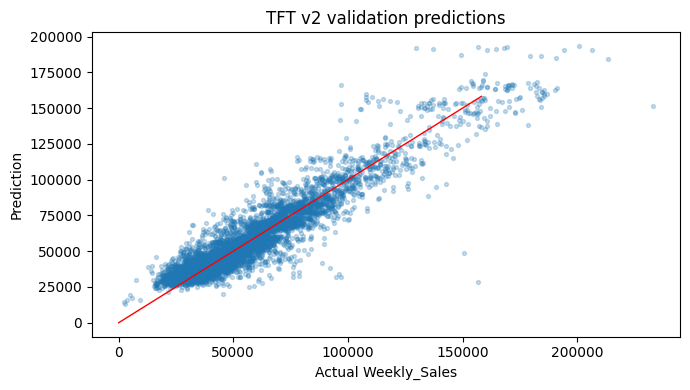

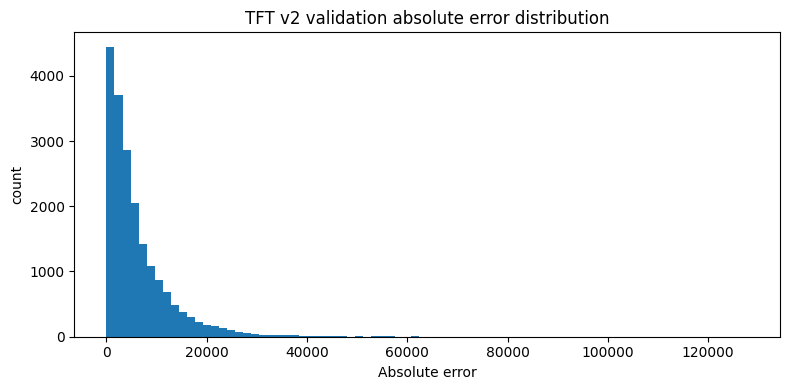

{'model': 'TemporalFusionTransformer',
 'experiment': 'tft_v2_log_target_external_covariates',
 'target_strategy': 'log1p_sales',
 'best_checkpoint_path': '/content/artifacts/tft_v2_log_target/checkpoints/tft-v2-epoch=07-val_loss=0.1205.ckpt',
 'best_val_loss': 0.12051758915185928,
 'best_validation_wmae': 6524.679969182181,
 'seasonal_naive_wmae': 4969.768735310006,
 'improvement_vs_seasonal_naive_pct': -31.287396188570963,
 'improvement_vs_v1_pct': -5.220577209814479,
 'validation_weeks': 39,
 'encoder_weeks': 39,
 'top_n_series': 500,
 'n_series': 500,
 'known_reals': ['time_idx',
  'week_sin',
  'week_cos',
  'month_sin',
  'month_cos',
  'Temperature',
  'Fuel_Price',
  'MarkDown1',
  'MarkDown2',
  'MarkDown3',
  'MarkDown4',
  'MarkDown5',
  'CPI',
  'Unemployment',
  'Size'],
 'config': {'seed': 42,
  'validation_weeks': 39,
  'encoder_weeks': 39,
  'top_n_series': 500,
  'holiday_weight': 5.0,
  'batch_size': 512,
  'max_epochs': 10,
  'max_time_minutes': 25,
  'patience': 3,


In [49]:
val_pred_path = OUTPUT_DIR / 'tft_v2_validation_predictions.csv'
val_pred_df.to_csv(val_pred_path, index=False)
summary = {
    'model': 'TemporalFusionTransformer',
    'experiment': 'tft_v2_log_target_external_covariates',
    'target_strategy': 'log1p_sales',
    'best_checkpoint_path': str(best_checkpoint_path),
    'best_val_loss': best_val_loss,
    'best_validation_wmae': float(validation_wmae),
    'seasonal_naive_wmae': float(seasonal_naive_wmae),
    'improvement_vs_seasonal_naive_pct': float(improvement_vs_seasonal),
    'improvement_vs_v1_pct': float(improvement_vs_v1),
    'validation_weeks': CONFIG['validation_weeks'],
    'encoder_weeks': CONFIG['encoder_weeks'],
    'top_n_series': CONFIG['top_n_series'],
    'n_series': int(data[['Store', 'Dept']].drop_duplicates().shape[0]),
    'known_reals': KNOWN_REALS,
    'config': CONFIG,
}
summary_path = OUTPUT_DIR / 'tft_v2_summary.json'
summary_path.write_text(json.dumps(summary, indent=2))

fig, ax = plt.subplots(figsize=(7,4))
sample = val_pred_df.sample(min(7000, len(val_pred_df)), random_state=SEED)
ax.scatter(sample['Weekly_Sales'], sample['Prediction'], s=8, alpha=0.25)
max_axis = np.nanpercentile(sample[['Weekly_Sales', 'Prediction']].to_numpy(), 99)
ax.plot([0, max_axis], [0, max_axis], color='red', linewidth=1)
ax.set_title('TFT v2 validation predictions')
ax.set_xlabel('Actual Weekly_Sales')
ax.set_ylabel('Prediction')
plt.tight_layout()
scatter_path = OUTPUT_DIR / 'tft_v2_validation_scatter.png'
fig.savefig(scatter_path, dpi=160)
plt.show()

fig, ax = plt.subplots(figsize=(8,4))
ax.hist(val_pred_df['AbsError'], bins=80)
ax.set_title('TFT v2 validation absolute error distribution')
ax.set_xlabel('Absolute error')
ax.set_ylabel('count')
plt.tight_layout()
error_hist_path = OUTPUT_DIR / 'tft_v2_abs_error_hist.png'
fig.savefig(error_hist_path, dpi=160)
plt.show()

artifact = wandb.Artifact(CONFIG['artifact_name'], type='model')
artifact.add_file(str(best_checkpoint_path), name='tft_v2_best.ckpt')
artifact.add_file(str(summary_path))
artifact.add_file(str(val_pred_path))
artifact.add_file(str(scatter_path))
artifact.add_file(str(error_hist_path))
run.log_artifact(artifact, aliases=['experiment-v2', 'latest'])
wandb.log({
    'validation/prediction_table': wandb.Table(dataframe=val_pred_df.sample(min(20000, len(val_pred_df)), random_state=SEED)),
    'validation/scatter': wandb.Image(str(scatter_path)),
    'validation/abs_error_histogram': wandb.Image(str(error_hist_path)),
})
summary

In [50]:
wandb.finish()

epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇████
lr-Adam,▁▁▁▁▁▁▁▁▁▁
train_loss_epoch,█▆▅▅▄▄▃▃▁▁
train_loss_step,█▅▅▆█▆▄▃▅▆▅▄▇▃▄▄▄▃▄▂▄▄▂▁▂
trainer/global_step,▁▁▂▂▂▂▂▂▂▂▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
val_MAE,██▆▅▃▃▂▁▂▂
val_MAPE,██▆▅▃▃▂▁▂▃
val_RMSE,▇█▇▆▃▃▂▁▂▃
val_SMAPE,██▆▅▃▃▂▁▂▂
val_loss,██▆▅▃▃▂▁▂▂
+4,...
